### Importación de Librerías
Importamos las herramientas necesarias:
* **Pandas y NumPy:** Para manipulación de datos.
* **Matplotlib:** Para gráficos básicos.
* **Scikit-Learn:** Para dividir los datos (`train_test_split`), crear el modelo (`DecisionTreeClassifier`) y evaluar resultados.
* **Graphviz:** Para generar la visualización gráfica del árbol.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from graphviz import Source

### Carga del Dataset
Descargamos los datos de estrellas directamente desde el repositorio.
Definimos:
* **y (Target):** La columna 'Star category' (lo que queremos predecir).
* **X (Features):** El resto de columnas (propiedades de la estrella).

In [ ]:
# Cargamos y preprocesamiento de datos
url = 'https://github.com/YBIFoundation/Dataset/raw/main/Stars.csv'
star = pd.read_csv(url)

# Separar variables predictoras (X) y objetivo (y)
y = star['Star category']
X = star.drop('Star category', axis=1)

### Preprocesamiento: One-Hot Encoding
Los Árboles de Decisión de Scikit-Learn no aceptan texto (strings).
* Usamos `pd.get_dummies` para convertir las columnas categóricas ('Color', 'Spectral_Class') en números binarios (0 y 1).
* Dividimos el dataset: 80% para entrenar (**Train**) y 20% para validar (**Test**).

In [ ]:
# El dataset tiene columnas de texto ('Color', 'Spectral_Class')
# Los árboles de decisión en sklearn requieren datos numéricos
# Usamos get_dummies para convertirlas (One-Hot Encoding)
Xs = pd.get_dummies(X, drop_first=True)

# Separamos los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42)

### Árbol Sin Restricciones
Entrenamos el primer modelo sin limitar su crecimiento (sin `max_depth` ni `min_samples...`).
* **Consecuencia:** El árbol crecerá tanto como necesite para clasificar perfectamente los datos de entrenamiento, volviéndose muy complejo y profundo.

In [ ]:
# Entrenamos el árbol de decisión
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Evaluación del Primer Árbol
Generamos la Matriz de Confusión usando el conjunto de prueba (`X_test`).
Esto nos permite ver cuántas estrellas ha clasificado correctamente y en qué categorías se equivoca.

Matriz de Confusión (Test Set)


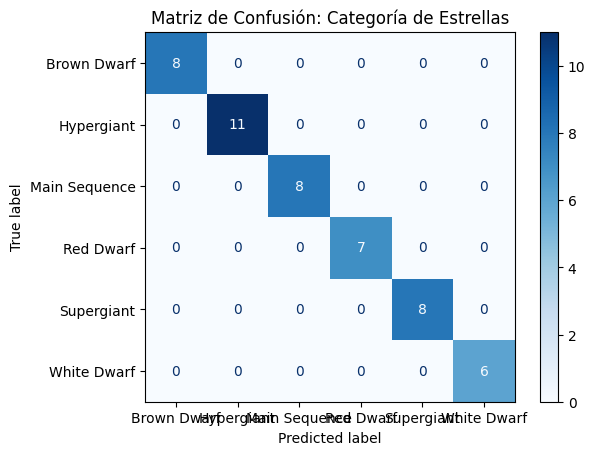

In [ ]:
# Mostramos la matriz de confusión
print("Matriz de Confusión (Test Set)")
y_pred = tree_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualización gráfica de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión: Categoría de Estrellas")
plt.show()

### Visualización del Grafo Completo
Dibujamos el primer árbol. Observaremos que es muy grande, con muchas ramas y nodos, debido a que no le pusimos límites de crecimiento.

Grafo del Árbol 1:


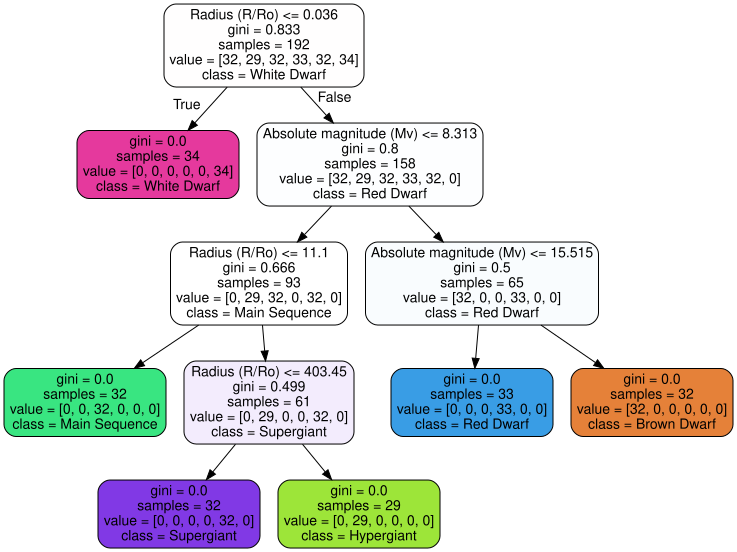

In [ ]:
# Visualización Árbol 1
from graphviz import Source

print("Grafo del Árbol 1:")
dot_data = export_graphviz(
    tree_clf,
    out_file=None,
    feature_names=X_train.columns,
    class_names=tree_clf.classes_.astype(str),
    rounded=True,
    filled=True
)
Source(dot_data)

### Árbol con Poda (Pruning)
Entrenamos un segundo modelo aplicando el hiperparámetro `min_samples_split=62`.
* **Objetivo:** Frenar la expansión.
* **Lógica:** Si un nodo tiene menos de 62 muestras, se prohíbe dividirlo más. Esto fuerza al árbol a ser más pequeño y generalista.

In [ ]:
# Árbol con Poda (Pruning)

# Elegimos un valor alto
tree_clf_pruned = DecisionTreeClassifier(min_samples_split=62, random_state=42)
tree_clf_pruned.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_split=62, random_state=42)

### Evaluación del Segundo Árbol
Mostramos la matriz de confusión del modelo podado para comparar su precisión con el modelo complejo. A veces, un modelo más simple funciona igual de bien (o mejor) porque evita el sobreajuste.

Matriz de Confusión (Test Set)


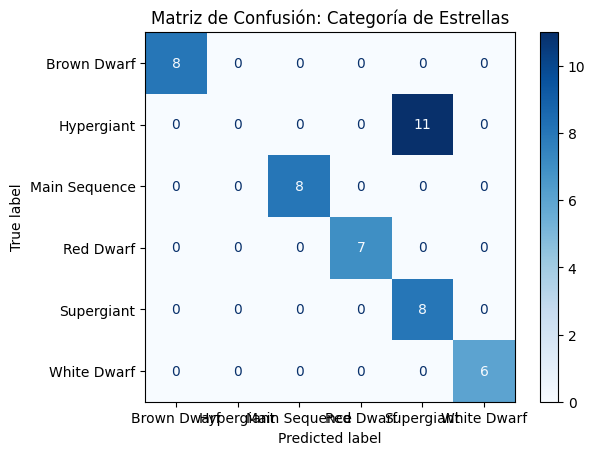

In [ ]:
# Mostramos la matriz de confusión
print("Matriz de Confusión (Test Set)")
y_pred = tree_clf_pruned.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualización gráfica de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión: Categoría de Estrellas")
plt.show()

### Visualización Comparativa
Dibujamos el segundo árbol.
Podremos observar visualmente que este grafo es **mucho más pequeño** y tiene menos profundidad que el primero, cumpliendo el objetivo de limitar la expansión mediante `min_samples_split`.


Grafo del Árbol 2 (Limitado con min_samples_split=62):
Profundidad Árbol 1: 4
Profundidad Árbol 2: 3


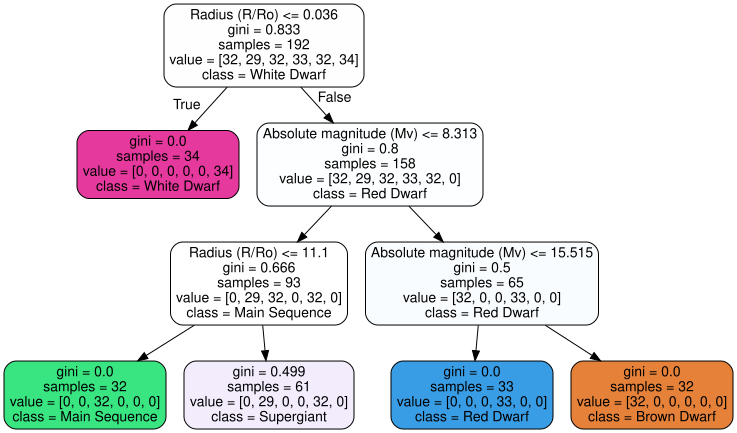

In [ ]:
# Visualizamos para comparar
print(f"\nGrafo del Árbol 2 (Limitado con min_samples_split=62):")
print(f"Profundidad Árbol 1: {tree_clf.get_depth()}")
print(f"Profundidad Árbol 2: {tree_clf_pruned.get_depth()}")

dot_data_pruned = export_graphviz(
    tree_clf_pruned,
    out_file=None,
    feature_names=X_train.columns,
    class_names=tree_clf_pruned.classes_.astype(str),
    rounded=True,
    filled=True
)
Source(dot_data_pruned)